In [ ]:
!pip install transformers datasets scikit-learn torch

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from transformers import RobertaTokenizer, RobertaForSequenceClassification, Trainer, TrainingArguments
import numpy as np
from datasets import Dataset
import torch
from torch.utils.data import Dataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from transformers import EarlyStoppingCallback

/home/bryan_santosa/conda_envs/torchgpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv('data_for_embedding.csv', sep=';')

In [4]:
df['label'].value_counts()

label
No Online Gambling Promotion    7821
Online Gambling Promotion       4179
Name: count, dtype: int64

In [5]:
df = df.drop(['video_id', 'video_title'], axis=1)

In [6]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   comment  12000 non-null  object
 1   label    12000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 187.6+ KB


In [8]:
xtemp, xtest, ytemp, ytest = train_test_split(df['comment'], df['label'], test_size=0.2, stratify=df['label'], random_state=42)

xtemp = np.array(xtemp)
ytemp = np.array(ytemp)

In [9]:
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

def tokenize(t):
  return tokenizer(t.tolist(), padding=True, truncation=True, return_tensors=None)

In [10]:
class CommentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
def model_initialize():
    return RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision_weighted": precision_score(labels, preds, average="weighted"),
        "recall_weighted": recall_score(labels, preds, average="weighted"),
        "f1_weighted": f1_score(labels, preds, average="weighted")
    }

In [12]:
learning_rates = [2e-5, 3e-5]
epochs = [2]

best_metric = -999
best_model_state = None
best_hp = None
fold_scores = []

In [ ]:
skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

best_metric = -999
best_hp = None
best_model_state = None
fold_scores = []

for lr in learning_rates:
    for ep in epochs:

        print(f"\n### Trying HP: LR={lr}, epochs={ep} ###")

        fold_metrics = []

        for fold, (train_idx, val_idx) in enumerate(skf.split(xtemp, ytemp)):
            print(f"\n===== Fold {fold+1} =====")

            xtr, xval = xtemp[train_idx], xtemp[val_idx]
            ytr, yval = ytemp[train_idx], ytemp[val_idx]

            # Tokenize
            xtr_t = tokenize(xtr)
            xval_t = tokenize(xval)

            train_d = CommentDataset(xtr_t, ytr.tolist())
            val_d = CommentDataset(xval_t, yval.tolist())

            # Model
            model = RobertaForSequenceClassification.from_pretrained(
                "roberta-base",num_labels=2
            )

            training_args = TrainingArguments(
                output_dir=f'./result_hp_{lr}_{ep}',
                num_train_epochs=ep,
                per_device_train_batch_size=16,
                per_device_eval_batch_size=64,
                learning_rate=lr,
                warmup_steps=200,
                weight_decay=0.01,
                logging_steps=20,
                eval_strategy="epoch",

                # ---- FIXED ----
                metric_for_best_model="eval_f1_weighted",
                greater_is_better=True,
                save_strategy="epoch",

                load_best_model_at_end=True
            )

            trainer = Trainer(
                model=model,
                args=training_args,
                train_dataset=train_d,
                eval_dataset=val_d,

                # ---- FIXED ----
                compute_metrics=lambda pred: {
                    "accuracy": accuracy_score(pred.label_ids, pred.predictions.argmax(-1)),
                    "f1_weighted": f1_score(pred.label_ids, pred.predictions.argmax(-1), average="weighted"),
                    "precision_weighted": precision_score(pred.label_ids, pred.predictions.argmax(-1), average="weighted"),
                    "recall_weighted": recall_score(pred.label_ids, pred.predictions.argmax(-1), average="weighted")
                },

                tokenizer=tokenizer,
                callbacks=[EarlyStoppingCallback(1)]
            )

            trainer.train()
            eval_result = trainer.evaluate()

            # ---- FIXED ----
            fold_metrics.append(eval_result["eval_f1_weighted"])

        # CV Mean weighted F1 for this hyperparameter
        avg_f1 = np.mean(fold_metrics)
        fold_scores.append(avg_f1)

        print(f"Average weighted F1 for LR={lr}, EP={ep}: {avg_f1:.4f}")

        # ---- FIXED ----
        if avg_f1 > best_metric:
            best_metric = avg_f1
            best_hp = (lr, ep)
            best_model_state = trainer.model.state_dict().copy()



### Trying HP: LR=2e-05, epochs=2 ###

===== Fold 1 =====


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_24875/678065917.py:53: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,Precision Weighted,Recall Weighted
1,0.196300,0.205313,0.931667,0.932072,0.933203,0.931667
2,0.122200,0.193445,0.943542,0.943623,0.943743,0.943542



===== Fold 2 =====


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_24875/678065917.py:53: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,Precision Weighted,Recall Weighted
1,0.210300,0.208074,0.931250,0.931133,0.931067,0.931250
2,0.136400,0.202637,0.937500,0.937709,0.938136,0.937500



===== Fold 2 =====


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_24875/678065917.py:53: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,Precision Weighted,Recall Weighted
1,0.268000,0.193879,0.936667,0.936658,0.936649,0.936667
2,0.206300,0.181428,0.942917,0.943010,0.943155,0.942917


Average weighted F1 for LR=3e-05, EP=2: 0.9404


In [14]:
torch.save(best_model_state, "roberta_best_model.bin")
print("Saved best model to roberta_best_model.bin")


Saved best model to roberta_best_model.bin


In [16]:
xtest_t = tokenizer(xtest.tolist(), padding=True, truncation=True)
test_d = CommentDataset(xtest_t, ytest.tolist())

final_model = RobertaForSequenceClassification.from_pretrained("roberta-base",num_labels=2)
final_model.load_state_dict(torch.load("roberta_best_model.bin", map_location="cpu"))
final_model.eval()

test_args = TrainingArguments(
    output_dir="./final_eval",
    per_device_eval_batch_size=64,
    do_train=False,
    do_eval=True,
    logging_steps=20
)
final_trainer = Trainer(
    model=final_model,
    args=test_args,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    eval_dataset=test_d
)
test_metrics = final_trainer.evaluate(test_d)
print("\n==== Test Set Metrics ====")
print(test_metrics)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_24875/554557431.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allow


==== Test Set Metrics ====
{'eval_loss': 0.17302928864955902, 'eval_model_preparation_time': 0.0021, 'eval_accuracy': 0.9520833333333333, 'eval_precision_weighted': 0.9521263925486068, 'eval_recall_weighted': 0.9520833333333333, 'eval_f1_weighted': 0.9521032437810946, 'eval_runtime': 118.5644, 'eval_samples_per_second': 20.242, 'eval_steps_per_second': 0.321}


In [17]:
def bootstrap_ci(labels, preds, metric_fn, n=1000):
    stats = []
    labels, preds = np.array(labels), np.array(preds)
    for _ in range(n):
        idx = np.random.choice(len(labels), len(labels), replace=True)
        stats.append(metric_fn(labels[idx], preds[idx]))
    return np.mean(stats), 1.96*np.std(stats)

pred_output = final_trainer.predict(test_d)
preds = np.argmax(pred_output.predictions, axis=1)
probs = pred_output.predictions
labels = pred_output.label_ids

test_mean, test_ci = bootstrap_ci(labels, preds,
    lambda a,b: f1_score(a,b,average='weighted')
)

print(f"\nTest Weighted F1 (bootstrap): {test_mean:.4f} ± {test_ci:.4f}\n")



Test Weighted F1 (bootstrap): 0.9519 ± 0.0087



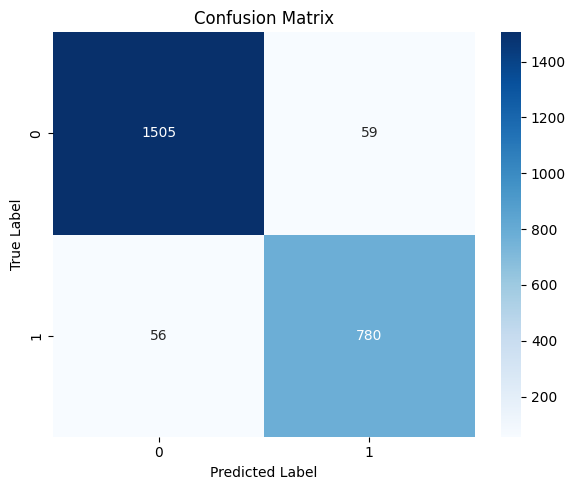

In [18]:
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


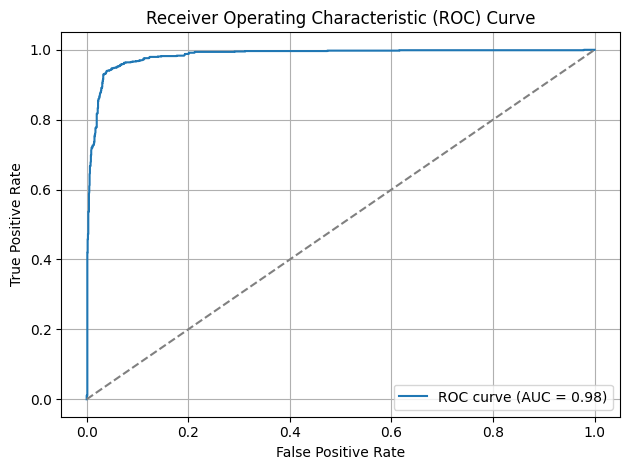

ROC AUC Score: 0.983909


In [23]:
from sklearn.preprocessing import label_binarize

# Binary classification assumed (labels: 0, 1)
fpr, tpr, thresholds = roc_curve(labels, probs[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print(f"ROC AUC Score: {roc_auc:.6f}")

In [20]:
print("Classification Report:")
print(classification_report(labels, preds))


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1564
           1       0.93      0.93      0.93       836

    accuracy                           0.95      2400
   macro avg       0.95      0.95      0.95      2400
weighted avg       0.95      0.95      0.95      2400



In [21]:
model.save_pretrained('hp_saved_model/RoBERTabase')
tokenizer.save_pretrained('hp_saved_model/RoBERTabase')

('hp_saved_model/RoBERTabase/tokenizer_config.json',
 'hp_saved_model/RoBERTabase/special_tokens_map.json',
 'hp_saved_model/RoBERTabase/vocab.json',
 'hp_saved_model/RoBERTabase/merges.txt',
 'hp_saved_model/RoBERTabase/added_tokens.json')

In [22]:
acc  = accuracy_score(labels, preds)
f1_w = f1_score(labels, preds, average='weighted')
prec_w = precision_score(labels, preds, average='weighted')
rec_w = recall_score(labels, preds, average='weighted')
print(f"Accuracy (weighted):       {acc:.6f}")
print(f"Precision (weighted):      {prec_w:.6f}")
print(f"Recall (weighted):         {rec_w:.6f}")
print(f"F1-Score (weighted):       {f1_w:.6f}")

Accuracy (weighted):       0.952083
Precision (weighted):      0.952126
Recall (weighted):         0.952083
F1-Score (weighted):       0.952103
